In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [36]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA: 12.8


In [43]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../Data/plantvillage/color",
    transform=transform
)

print("Images:", len(dataset))
print("Classes:", len(dataset.classes))

Images: 54305
Classes: 38


In [44]:
dataset_size = len(dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 43444
Validation: 5430
Test: 5431


In [ ]:
# data loaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [ ]:
# final CNN

In [ ]:
class PlantDiseaseCNN(nn.Module):

    def __init__(self, num_classes=38):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x

In [ ]:
#model creation

In [ ]:
model = PlantDiseaseCNN(
    num_classes=len(dataset.classes)
).to(device)

print(model)

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-

In [ ]:
# parameter count

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters: 98598
Trainable Parameters: 98598


In [ ]:
# Loss function and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
# mixed precision training here amp is used to speed up training and reduce memory usage by using half-precision floating point numbers (float16) instead of full-precision (float32). This can be particularly beneficial when training deep learning models on GPUs that support mixed precision.

In [ ]:
scaler = torch.amp.GradScaler("cuda")

In [ ]:
# Training Function

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
# Validation loop

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
# Training Loop

In [ ]:
import time

model.train()

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

start = time.time()

with torch.amp.autocast("cuda"):
    outputs = model(images)
    loss = criterion(outputs, labels)

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()

end = time.time()

print("One batch time:", end - start, "seconds")
print("GPU:", torch.cuda.get_device_name(0))

One batch time: 0.42504286766052246 seconds
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
num_epochs = 5

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "../Models/best_cnn.pth"
        )

        print("✓ Best model saved")

Epoch [1/5] | Train Loss: 3.3902 | Train Acc: 0.1350 | Val Loss: 3.0875 | Val Acc: 0.1733
✓ Best model saved
Epoch [2/5] | Train Loss: 2.9504 | Train Acc: 0.2027 | Val Loss: 2.6900 | Val Acc: 0.2792
✓ Best model saved
Epoch [3/5] | Train Loss: 2.6104 | Train Acc: 0.3128 | Val Loss: 2.3968 | Val Acc: 0.3867
✓ Best model saved
Epoch [4/5] | Train Loss: 2.3796 | Train Acc: 0.3819 | Val Loss: 2.2049 | Val Acc: 0.4499
✓ Best model saved
Epoch [5/5] | Train Loss: 2.2140 | Train Acc: 0.4248 | Val Loss: 2.0608 | Val Acc: 0.4735
✓ Best model saved


In [ ]:
# Training curves

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# accuracy curve

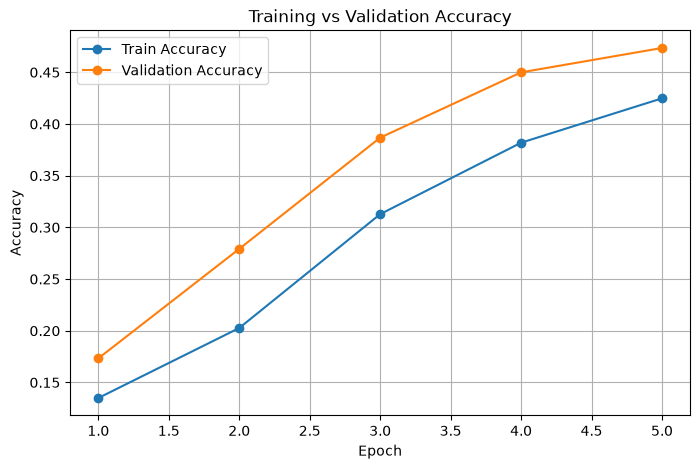

In [ ]:
epochs = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# loss curve

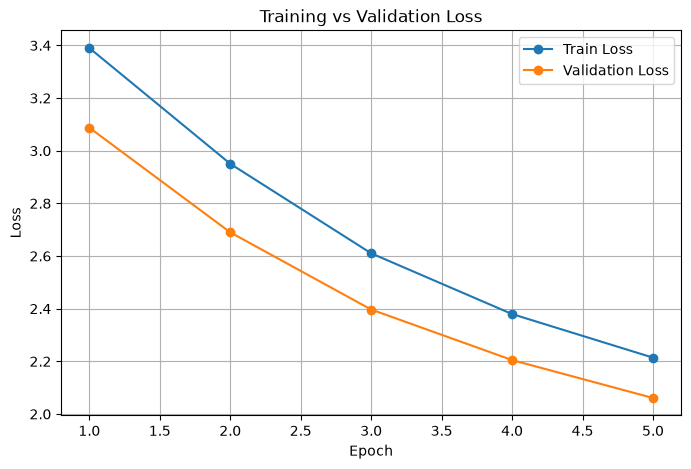

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# retrain
start_epoch = 5
total_epochs = 10

for epoch in range(start_epoch, total_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{total_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "../Models/best_cnn.pth"
        )

        print("✓ Best model saved")

Epoch [6/10] | Train Loss: 2.0895 | Train Acc: 0.4495 | Val Loss: 1.9424 | Val Acc: 0.4912
✓ Best model saved
Epoch [7/10] | Train Loss: 1.9790 | Train Acc: 0.4771 | Val Loss: 1.8468 | Val Acc: 0.5297
✓ Best model saved
Epoch [8/10] | Train Loss: 1.8779 | Train Acc: 0.5069 | Val Loss: 1.7345 | Val Acc: 0.5648
✓ Best model saved
Epoch [9/10] | Train Loss: 1.7780 | Train Acc: 0.5300 | Val Loss: 1.6472 | Val Acc: 0.5814
✓ Best model saved
Epoch [10/10] | Train Loss: 1.6782 | Train Acc: 0.5578 | Val Loss: 1.5118 | Val Acc: 0.6175
✓ Best model saved


In [ ]:
start_epoch = 10
total_epochs = 15

for epoch in range(start_epoch, total_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{total_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "../Models/best_cnn.pth"
        )

        print("✓ Best model saved")

Epoch [11/15] | Train Loss: 1.5772 | Train Acc: 0.5841 | Val Loss: 1.4112 | Val Acc: 0.6365
✓ Best model saved
Epoch [12/15] | Train Loss: 1.4677 | Train Acc: 0.6070 | Val Loss: 1.3567 | Val Acc: 0.6586
✓ Best model saved
Epoch [13/15] | Train Loss: 1.3490 | Train Acc: 0.6359 | Val Loss: 1.1963 | Val Acc: 0.7048
✓ Best model saved
Epoch [14/15] | Train Loss: 1.2364 | Train Acc: 0.6620 | Val Loss: 1.1155 | Val Acc: 0.7088
✓ Best model saved
Epoch [15/15] | Train Loss: 1.1263 | Train Acc: 0.6858 | Val Loss: 1.2041 | Val Acc: 0.6398


In [ ]:
# best model loading

In [ ]:
model.load_state_dict(
    torch.load("../Models/best_cnn.pth", weights_only=True)
)

model.eval()

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-

In [ ]:
# Test Accuracy

In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7151537470079176


In [ ]:
# Classification Report

from sklearn.metrics import classification_report

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.66      0.46      0.54        72
                                 Apple___Black_rot       0.65      0.17      0.27        64
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        23
                                   Apple___healthy       0.68      0.62      0.65       169
                               Blueberry___healthy       0.86      0.85      0.86       130
          Cherry_(including_sour)___Powdery_mildew       0.46      0.75      0.57       116
                 Cherry_(including_sour)___healthy       0.85      0.35      0.50        82
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.18      0.29        45
                       Corn_(maize)___Common_rust_       1.00      0.97      0.99       113
               Corn_(maize)___Northern_Leaf_Blight       0.69      0.93      0.

c:\Users\utyo1\anaconda3\envs\plant\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\utyo1\anaconda3\envs\plant\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\utyo1\anaconda3\envs\plant\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

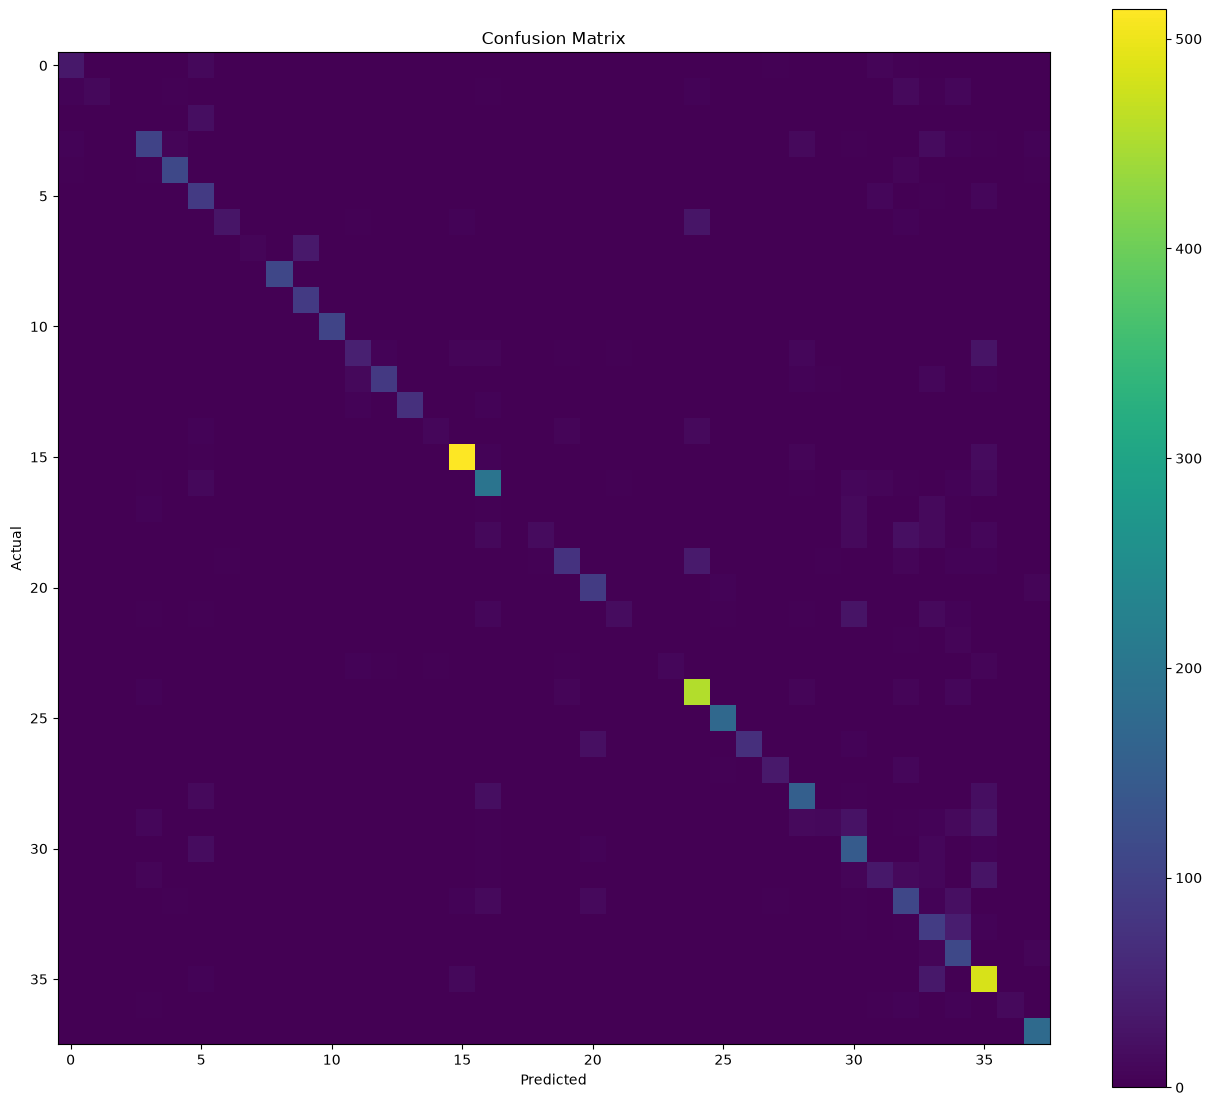

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(16, 14))
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Error Analysis
import numpy as np

errors = []

for actual in range(len(dataset.classes)):
    for predicted in range(len(dataset.classes)):
        if actual != predicted:
            errors.append((
                cm[actual, predicted],
                dataset.classes[actual],
                dataset.classes[predicted]
            ))

errors.sort(reverse=True)

for count, actual, predicted in errors[:10]:
    print(f"{count:3d} | {actual} → {predicted}")

 42 | Tomato___Spider_mites Two-spotted_spider_mite → Tomato___Target_Spot
 38 | Pepper,_bell___healthy → Soybean___healthy
 36 | Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Corn_(maize)___Northern_Leaf_Blight
 33 | Tomato___Tomato_Yellow_Leaf_Curl_Virus → Tomato___Spider_mites Two-spotted_spider_mite
 29 | Cherry_(including_sour)___healthy → Soybean___healthy
 28 | Tomato___Leaf_Mold → Tomato___Tomato_Yellow_Leaf_Curl_Virus
 27 | Tomato___Early_blight → Tomato___Tomato_Yellow_Leaf_Curl_Virus
 27 | Potato___Late_blight → Tomato___Late_blight
 27 | Grape___Black_rot → Tomato___Tomato_Yellow_Leaf_Curl_Virus
 25 | Tomato___Early_blight → Tomato___Late_blight


In [45]:
# ==============================
# AUGMENTED DATASET SETUP
# ==============================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch

# 1. Transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# 2. Create base dataset WITHOUT transform

base_dataset = datasets.ImageFolder(
    "../Data/plantvillage/color"
)

dataset_size = len(base_dataset)


# 3. Create SAME split as before

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    dataset_size,
    generator=generator
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]


# 4. Create datasets with different transforms

train_full = datasets.ImageFolder(
    "../Data/plantvillage/color",
    transform=train_transform
)

val_test_full = datasets.ImageFolder(
    "../Data/plantvillage/color",
    transform=val_test_transform
)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_test_full, val_indices)
test_dataset = Subset(val_test_full, test_indices)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 43444
Validation: 5430
Test: 5431


In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("DataLoaders ready!")

DataLoaders ready!


In [47]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


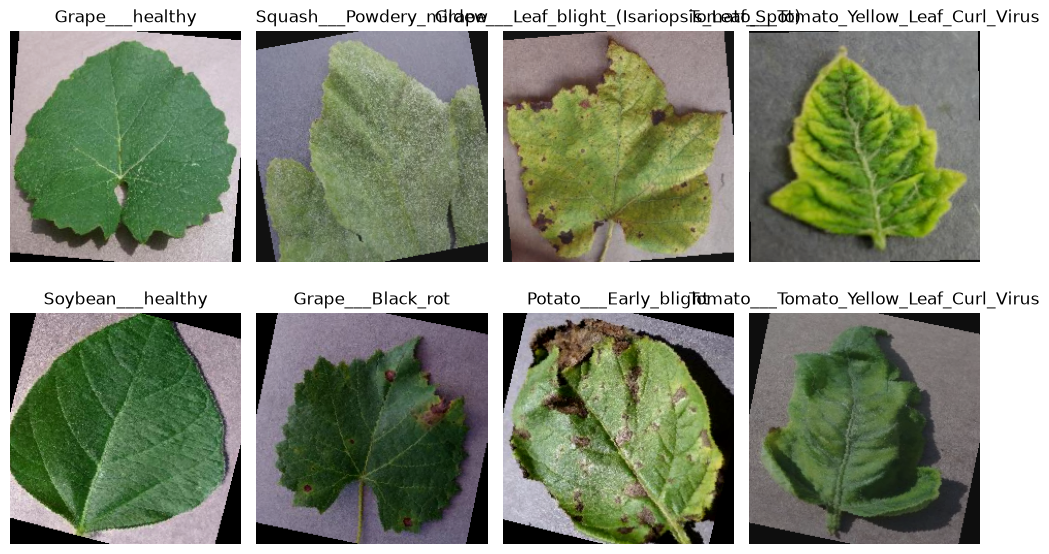

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# Fresh model for augmentation experiment

model_aug = PlantDiseaseCNN(
    num_classes=len(base_dataset.classes)
).to(device)

criterion_aug = nn.CrossEntropyLoss()

optimizer_aug = torch.optim.AdamW(
    model_aug.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scaler_aug = torch.amp.GradScaler("cuda")

print("Augmented model ready!")

Augmented model ready!


In [50]:
num_epochs = 10

best_val_accuracy_aug = 0.0

history_aug = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model_aug,
        train_loader,
        criterion_aug,
        optimizer_aug,
        scaler_aug,
        device
    )

    val_loss, val_accuracy = validate(
        model_aug,
        val_loader,
        criterion_aug,
        device
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["train_accuracy"].append(train_accuracy)

    history_aug["val_loss"].append(val_loss)
    history_aug["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

    if val_accuracy > best_val_accuracy_aug:

        best_val_accuracy_aug = val_accuracy

        torch.save(
            model_aug.state_dict(),
            "../Models/best_cnn_aug.pth"
        )

        print("✓ Best augmented model saved")

Epoch [1/10] | Train Acc: 0.5010 | Val Acc: 0.6525 | Train Loss: 1.8239 | Val Loss: 1.2119
✓ Best augmented model saved
Epoch [2/10] | Train Acc: 0.6701 | Val Acc: 0.6048 | Train Loss: 1.1314 | Val Loss: 1.2867
Epoch [3/10] | Train Acc: 0.7294 | Val Acc: 0.7757 | Train Loss: 0.9025 | Val Loss: 0.7440
✓ Best augmented model saved
Epoch [4/10] | Train Acc: 0.7647 | Val Acc: 0.7505 | Train Loss: 0.7790 | Val Loss: 0.7899
Epoch [5/10] | Train Acc: 0.7885 | Val Acc: 0.8155 | Train Loss: 0.6953 | Val Loss: 0.6100
✓ Best augmented model saved
Epoch [6/10] | Train Acc: 0.8071 | Val Acc: 0.8669 | Train Loss: 0.6260 | Val Loss: 0.4526
✓ Best augmented model saved
Epoch [7/10] | Train Acc: 0.8206 | Val Acc: 0.8676 | Train Loss: 0.5791 | Val Loss: 0.4385
✓ Best augmented model saved
Epoch [8/10] | Train Acc: 0.8335 | Val Acc: 0.8466 | Train Loss: 0.5424 | Val Loss: 0.5084
Epoch [9/10] | Train Acc: 0.8455 | Val Acc: 0.8794 | Train Loss: 0.5034 | Val Loss: 0.4031
✓ Best augmented model saved
Epoch [

In [51]:
model_aug.load_state_dict(
    torch.load("../Models/best_cnn_aug.pth", weights_only=True)
)

model_aug.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy_aug = correct / total

print("Augmented Test Accuracy:", test_accuracy_aug)

Augmented Test Accuracy: 0.8722150616829313


In [ ]:
#Transfer Learning with EfficientNetB0

In [53]:
from torchvision import models
import torch.nn as nn

In [54]:
efficientnet = models.efficientnet_b0(
    weights="DEFAULT"
)

print(efficientnet)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\utyo1/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:18<00:00, 1.16MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [55]:
num_classes = len(base_dataset.classes)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    num_classes
)

efficientnet = efficientnet.to(device)

print(efficientnet.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=38, bias=True)
)


In [56]:
# Freeze pretrained layers

for param in efficientnet.features.parameters():
    param.requires_grad = False

print("Pretrained layers frozen")

Pretrained layers frozen


In [57]:
trainable_params = sum(
    p.numel()
    for p in efficientnet.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)

Trainable parameters: 48678


In [58]:
criterion_eff = nn.CrossEntropyLoss()

optimizer_eff = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        efficientnet.parameters()
    ),
    lr=0.001,
    weight_decay=1e-4
)

scaler_eff = torch.amp.GradScaler("cuda")

print("EfficientNet training setup ready!")

EfficientNet training setup ready!


In [59]:
num_epochs = 5

best_val_accuracy_eff = 0.0

history_eff = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        efficientnet,
        train_loader,
        criterion_eff,
        optimizer_eff,
        scaler_eff,
        device
    )

    val_loss, val_accuracy = validate(
        efficientnet,
        val_loader,
        criterion_eff,
        device
    )

    history_eff["train_loss"].append(train_loss)
    history_eff["train_accuracy"].append(train_accuracy)

    history_eff["val_loss"].append(val_loss)
    history_eff["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

    if val_accuracy > best_val_accuracy_eff:

        best_val_accuracy_eff = val_accuracy

        torch.save(
            efficientnet.state_dict(),
            "../Models/best_efficientnet.pth"
        )

        print("✓ Best EfficientNet saved")

Epoch [1/5] | Train Acc: 0.8553 | Val Acc: 0.9424 | Train Loss: 0.6828 | Val Loss: 0.2450
✓ Best EfficientNet saved
Epoch [2/5] | Train Acc: 0.9322 | Val Acc: 0.9569 | Train Loss: 0.2559 | Val Loss: 0.1734
✓ Best EfficientNet saved
Epoch [3/5] | Train Acc: 0.9431 | Val Acc: 0.9576 | Train Loss: 0.2019 | Val Loss: 0.1494
✓ Best EfficientNet saved
Epoch [4/5] | Train Acc: 0.9488 | Val Acc: 0.9624 | Train Loss: 0.1738 | Val Loss: 0.1310
✓ Best EfficientNet saved
Epoch [5/5] | Train Acc: 0.9500 | Val Acc: 0.9645 | Train Loss: 0.1621 | Val Loss: 0.1187
✓ Best EfficientNet saved


In [61]:
start_epoch = 5
total_epochs = 10

patience = 2
no_improve = 0

for epoch in range(start_epoch, total_epochs):

    train_loss, train_accuracy = train_one_epoch(
        efficientnet,
        train_loader,
        criterion_eff,
        optimizer_eff,
        scaler_eff,
        device
    )

    val_loss, val_accuracy = validate(
        efficientnet,
        val_loader,
        criterion_eff,
        device
    )

    history_eff["train_loss"].append(train_loss)
    history_eff["train_accuracy"].append(train_accuracy)
    history_eff["val_loss"].append(val_loss)
    history_eff["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{total_epochs}] "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

    if val_accuracy > best_val_accuracy_eff:

        best_val_accuracy_eff = val_accuracy
        no_improve = 0

        torch.save(
            efficientnet.state_dict(),
            "../Models/best_efficientnet.pth"
        )

        print("✓ Best EfficientNet saved")

    else:
        no_improve += 1

        print(f"No improvement: {no_improve}/{patience}")

        if no_improve >= patience:
            print("🛑 Early stopping triggered")
            break

Epoch [6/10] | Train Acc: 0.9530 | Val Acc: 0.9676 | Train Loss: 0.1526 | Val Loss: 0.1172
✓ Best EfficientNet saved
Epoch [7/10] | Train Acc: 0.9545 | Val Acc: 0.9654 | Train Loss: 0.1448 | Val Loss: 0.1073
No improvement: 1/2
Epoch [8/10] | Train Acc: 0.9542 | Val Acc: 0.9698 | Train Loss: 0.1407 | Val Loss: 0.0976
✓ Best EfficientNet saved
Epoch [9/10] | Train Acc: 0.9579 | Val Acc: 0.9678 | Train Loss: 0.1345 | Val Loss: 0.0982
No improvement: 1/2
Epoch [10/10] | Train Acc: 0.9591 | Val Acc: 0.9680 | Train Loss: 0.1290 | Val Loss: 0.0971
No improvement: 2/2
🛑 Early stopping triggered


In [62]:
efficientnet.load_state_dict(
    torch.load(
        "../Models/best_efficientnet.pth",
        weights_only=True
    )
)

efficientnet.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy_eff = correct / total

print("EfficientNet Test Accuracy:", test_accuracy_eff)

EfficientNet Test Accuracy: 0.973117289633585


In [63]:
from sklearn.metrics import classification_report

all_predictions_eff = []
all_labels_eff = []

efficientnet.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = efficientnet(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_eff.extend(
            predictions.cpu().numpy()
        )
        all_labels_eff.extend(
            labels.numpy()
        )

print(
    classification_report(
        all_labels_eff,
        all_predictions_eff,
        target_names=base_dataset.classes
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.94      0.96        72
                                 Apple___Black_rot       1.00      1.00      1.00        64
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        23
                                   Apple___healthy       1.00      0.95      0.98       169
                               Blueberry___healthy       0.98      0.99      0.98       130
          Cherry_(including_sour)___Powdery_mildew       0.97      0.99      0.98       116
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99        82
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.71      0.79        45
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       113
               Corn_(maize)___Northern_Leaf_Blight       0.87      0.96      0.

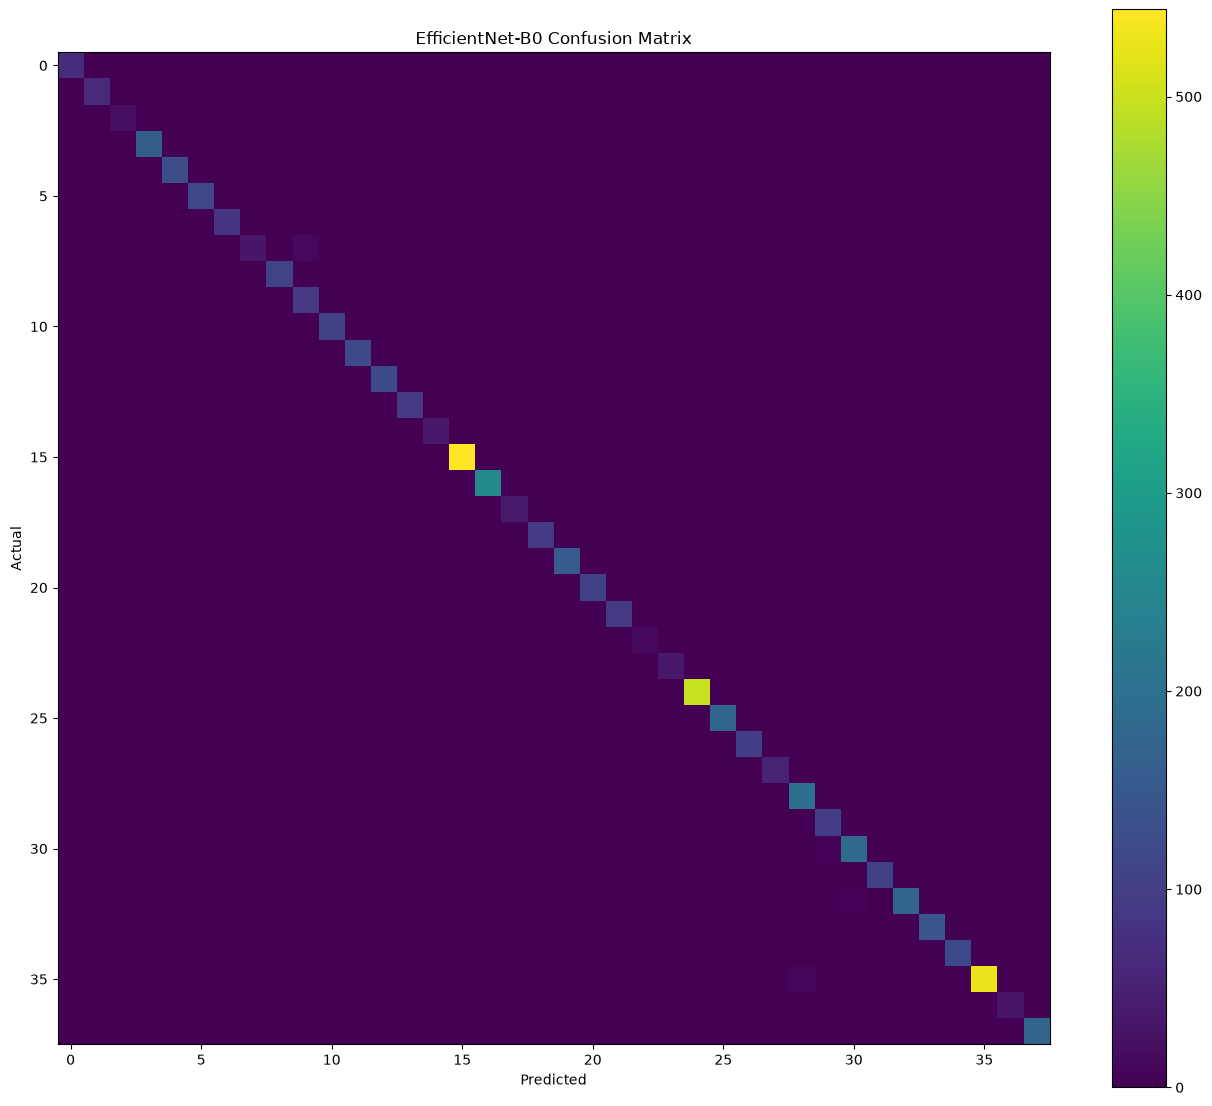

In [64]:
# final model confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_eff = confusion_matrix(
    all_labels_eff,
    all_predictions_eff
)

plt.figure(figsize=(16, 14))

plt.imshow(cm_eff)
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet-B0 Confusion Matrix")

plt.show()

In [ ]:
# hyperparameter tuning with Optuna

In [65]:
pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached colorlog-6.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.51-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached greenlet-3.5.4-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached sqlalchemy-2.0.51-cp312-cp312-win_amd64.whl (2.1 MB)
Using cached greenlet-3.5.4-cp312-cp312-win_amd64.whl (247 kB)
Using cached colorlog-6.12.0-py3-none-any.whl (12 kB)

   ------ --------------------------------- 1/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]


In [66]:
import optuna
import copy

def objective(trial):

    # Hyperparameters
    lr = trial.suggest_float(
        "lr",
        1e-5,
        1e-3,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    dropout = trial.suggest_float(
        "dropout",
        0.2,
        0.5
    )

    # Fresh EfficientNet
    model = models.efficientnet_b0(
        weights="DEFAULT"
    )

    # Replace classifier
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 38)
    )

    # Freeze pretrained features
    for param in model.features.parameters():
        param.requires_grad = False

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    scaler = torch.amp.GradScaler("cuda")

    # Quick training for each trial
    for epoch in range(2):

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
            device
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion,
            device
        )

        trial.report(val_acc, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

In [67]:
study = optuna.create_study(
    direction="maximize",
    study_name="efficientnet_tuning"
)

study.optimize(
    objective,
    n_trials=10
)

[I 2026-08-09 00:27:35,389] A new study created in memory with name: efficientnet_tuning
[I 2026-08-09 00:29:40,990] Trial 0 finished with value: 0.6576427255985267 and parameters: {'lr': 2.9690872301385145e-05, 'weight_decay': 1.0058611781945558e-06, 'dropout': 0.4888271265290708}. Best is trial 0 with value: 0.6576427255985267.
[I 2026-08-09 00:31:50,622] Trial 1 finished with value: 0.9265193370165746 and parameters: {'lr': 0.00025061648745653065, 'weight_decay': 8.148678172722742e-06, 'dropout': 0.24355386041161473}. Best is trial 1 with value: 0.9265193370165746.
[I 2026-08-09 00:34:10,872] Trial 2 finished with value: 0.7014732965009208 and parameters: {'lr': 3.110234836813778e-05, 'weight_decay': 0.0002962717108617917, 'dropout': 0.37990889429284463}. Best is trial 1 with value: 0.9265193370165746.
[I 2026-08-09 00:36:46,563] Trial 3 finished with value: 0.5233885819521179 and parameters: {'lr': 1.543624394059527e-05, 'weight_decay': 7.259900124114343e-05, 'dropout': 0.201006256

In [68]:
print("Best Trial:", study.best_trial.number)
print("Best Validation Accuracy:", study.best_value)
print("Best Parameters:", study.best_params)

Best Trial: 1
Best Validation Accuracy: 0.9265193370165746
Best Parameters: {'lr': 0.00025061648745653065, 'weight_decay': 8.148678172722742e-06, 'dropout': 0.24355386041161473}


In [69]:
# final model creation with the hyperparameters found
best_params = study.best_params

tuned_eff = models.efficientnet_b0(weights="DEFAULT")

in_features = tuned_eff.classifier[1].in_features

tuned_eff.classifier = nn.Sequential(
    nn.Dropout(best_params["dropout"]),
    nn.Linear(in_features, len(base_dataset.classes))
)

# Freeze pretrained features
for param in tuned_eff.features.parameters():
    param.requires_grad = False

tuned_eff = tuned_eff.to(device)

criterion_tuned = nn.CrossEntropyLoss()

optimizer_tuned = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, tuned_eff.parameters()),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

scaler_tuned = torch.amp.GradScaler("cuda")

print("Tuned EfficientNet ready!")
print(best_params)

Tuned EfficientNet ready!
{'lr': 0.00025061648745653065, 'weight_decay': 8.148678172722742e-06, 'dropout': 0.24355386041161473}


In [ ]:
num_epochs = 10
patience = 2

best_val_acc_tuned = 0.0
no_improve = 0

history_tuned = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        tuned_eff,
        train_loader,
        criterion_tuned,
        optimizer_tuned,
        scaler_tuned,
        device
    )

    val_loss, val_acc = validate(
        tuned_eff,
        val_loader,
        criterion_tuned,
        device
    )

    history_tuned["train_loss"].append(train_loss)
    history_tuned["train_accuracy"].append(train_acc)
    history_tuned["val_loss"].append(val_loss)
    history_tuned["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

    if val_acc > best_val_acc_tuned:

        best_val_acc_tuned = val_acc
        no_improve = 0

        torch.save(
            tuned_eff.state_dict(),
            "../Models/best_tuned_efficientnet.pth"
        )

        print("✓ Best tuned model saved")

    else:
        no_improve += 1

        print(f"No improvement: {no_improve}/{patience}")

        if no_improve >= patience:
            print("🛑 Early stopping")
            break

Epoch [1/10] | Train Acc: 0.7256 | Val Acc: 0.8969 | Train Loss: 1.4601 | Val Loss: 0.6256
✓ Best tuned model saved
